In [1]:
%matplotlib inline
import numpy as np

import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
import os
from scipy.integrate import simps
import astropy.units as u
import astropy.constants as c
from astropy.coordinates import SkyCoord
import matplotlib.ticker as ticker

k = 1.82224e18
m_H = c.m_p + c.m_e
m_H = m_H.to('M_sun')

In [2]:
m_H

<Quantity 8.41643811e-58 solMass>

In [3]:

fname ='gass_10_40_1670381041.fits'

fits_data = fits.open(fname)

fits_data[0].header


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                   13 / length of data axis 1                          
NAXIS2  =                   25 / length of data axis 2                          
NAXIS3  =                 1201 / length of data axis 3                          
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CTYPE1  = 'RA---CAR'           / axis type                                      
CRVAL1  =   1.021041666667E+01 / longitude                                      
CRPIX1  =   7.000000000000E+00 / ref pixel                                      
CDELT1  =  -1.049799919128E-01 / longitude increment                            
CROTA1  =   0.000000000000E+

In [4]:
fits_data[0].data[0][1]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
      dtype=float32)

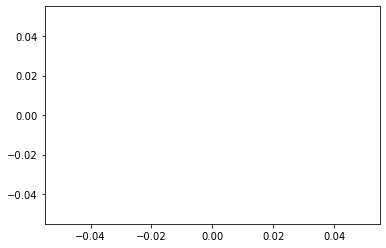

In [5]:
plt.plot(fits_data[0].data[0][0], fits_data[0].data[0][1], 'bo')

In [6]:
hdr = fits_data['PRIMARY'].header

In [7]:
hdr

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                   37 / length of data axis 1                          
NAXIS2  =                   37 / length of data axis 2                          
NAXIS3  =                  123 / length of data axis 3                          
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CTYPE1  = 'GLON-CAR'           / axis type                                      
CRVAL1  =  -8.750000000000E+01 / longitude                                      
CRPIX1  =   1.900000000000E+01 / ref pixel                                      
CDELT1  =  -3.090964423286E-01 / longitude increment                            
CROTA1  =   0.000000000000E+

In [8]:
data = fits_data[0].data

In [9]:
fits_data[0].data[0][0]

array([ 0.02000427, -0.02999878, -0.04750061, -0.00499725,  0.01499939,
        0.04499817,  0.04750061, -0.01750183, -0.02749634, -0.02500153,
        0.01250458,  0.06500244,  0.01000214, -0.03250122, -0.03749847,
       -0.02500153,  0.00749969,  0.02249908,  0.02000427,  0.02000427,
        0.04250336,  0.06000519,  0.04499817, -0.03250122, -0.04999542,
       -0.06499481, -0.05249786,  0.        , -0.00249481, -0.01499939,
       -0.00499725, -0.03250122, -0.02999878, -0.04750061, -0.09500122,
       -0.04249573, -0.03250122], dtype=float32)

In [10]:
vel = np.linspace(-200.,-100.,len(fits_data[0].data))
long = np.linspace(-89.,-86.,len(fits_data[0].data[0]))
lat = np.linspace(-76.5,-73.5,len(fits_data[0].data[0][0]))

In [11]:
lat

array([-76.5       , -76.41666667, -76.33333333, -76.25      ,
       -76.16666667, -76.08333333, -76.        , -75.91666667,
       -75.83333333, -75.75      , -75.66666667, -75.58333333,
       -75.5       , -75.41666667, -75.33333333, -75.25      ,
       -75.16666667, -75.08333333, -75.        , -74.91666667,
       -74.83333333, -74.75      , -74.66666667, -74.58333333,
       -74.5       , -74.41666667, -74.33333333, -74.25      ,
       -74.16666667, -74.08333333, -74.        , -73.91666667,
       -73.83333333, -73.75      , -73.66666667, -73.58333333,
       -73.5       ])

In [12]:
data_maxes = []


for i in range(123):
    for j in range(37):
        data_maxes.append(max(data[i][j]))
        if max(data[i][j]) == max(data_maxes):
            vel_index = i
            long_index = j
            lat_index = np.where(data[i][j] == max(data[i][j]))[0][0]
            
print(max(data_maxes))
print(vel_index)
print(long_index)
print(lat_index)

1.4274979
98
26
23


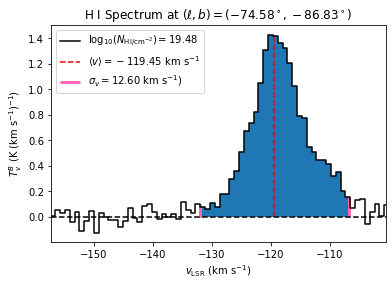

In [13]:
data_vtform = data.T

vel_more_stuff = np.linspace(vel[0],vel[-1],10000)
T_B_int = simps(data_vtform[23][26],x=vel)
NHI = np.log10(k*T_B_int)
plt.step(vel,data_vtform[23][26],'k-',label=r'$\log_{10}(N_{\rm{HI}/\rm{cm}^{-2}}) = %2.2f$' % NHI)

vel_avg = simps(data_vtform[23][26] * vel,x=vel)/T_B_int

inside_sqrt = simps(data_vtform[23][26] * (vel - vel_avg)**2) / T_B_int
vel_disp = np.sqrt(inside_sqrt)

plt.title(r'H I Spectrum at $(\ell,b) = (%3.2f^\circ,%3.2f^\circ)$' % (lat[23],long[26]))
plt.xlabel(r'$v_{\rm{LSR}}$ (km s$^{-1}$)')
plt.ylabel(r'$T^B_v$ (K (km s$^{-1})^{-1})$')
plt.vlines(x=vel_avg,ymin=0,ymax=max(data_vtform[23][26]),color='r',linestyle='dashed',label=r'$\langle v \rangle = %3.2f$ km s$^{-1}$' % vel_avg)
xmin = vel_avg-3.*vel_disp
xmax = vel_avg+1.5*vel_disp
plt.xlim(xmin=xmin,xmax = xmax)
epsilon = 0.3

index_sigmapl = np.where(abs(vel-(vel_avg + vel_disp)) < epsilon)[0][0]
TB_maxpl = data_vtform[23][26][index_sigmapl]
index_sigmamin = np.where(abs(vel-(vel_avg - vel_disp)) < epsilon)[0][0]
TB_maxmin = data_vtform[23][26][index_sigmamin]

dvel = vel[1] - vel[0]


plt.fill_between(vel[(vel>=vel_avg-vel_disp) & (vel <= vel_avg+vel_disp+dvel)], \
                 data_vtform[23][26][(vel>=vel_avg-vel_disp) & (vel <= vel_avg+vel_disp+dvel)],\
                step='pre')

plt.vlines(x=vel_avg+vel_disp,ymin=0,ymax=TB_maxpl,color='hotpink',linewidth=3.,label=r'$\sigma_v = %2.2f$ km s$^{-1})$' % vel_disp)
plt.vlines(x=vel_avg-vel_disp,ymin=0,ymax=TB_maxmin,color='hotpink',linewidth=3.)
plt.hlines(y=0.,xmin=xmin,xmax = xmax,linestyle='dashed',color='k')
plt.legend()

plt.savefig('Plots/Sample_HI_Spectrum_detection.pdf')
plt.show()

In [14]:
Temp = m_H * vel_disp**2 * (u.km/u.s)**2 /c.k_B
T = Temp.to('K')
np.log10(T/u.K)

<Quantity 4.28452719>

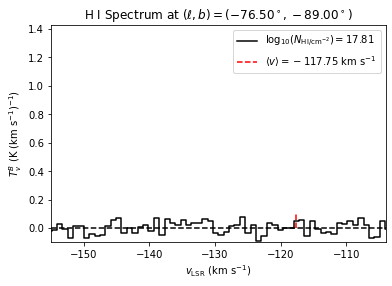

In [15]:
data_vtform = data.T

vel_more_stuff = np.linspace(vel[0],vel[-1],10000)
T_B_int = simps(data_vtform[0][0],x=vel)
NHI = np.log10(k*T_B_int)
plt.step(vel,data_vtform[0][0],'k-',label=r'$\log_{10}(N_{\rm{HI}/\rm{cm}^{-2}}) = %2.2f$' % NHI)

vel_avg = simps(data_vtform[0][26] * vel,x=vel)/T_B_int

inside_sqrt = simps(data_vtform[0][0] * (vel - vel_avg)**2) / T_B_int
vel_disp = np.sqrt(inside_sqrt)

plt.title(r'H I Spectrum at $(\ell,b) = (%3.2f^\circ,%3.2f^\circ)$' % (lat[0],long[0]))
plt.xlabel(r'$v_{\rm{LSR}}$ (km s$^{-1}$)')
plt.ylabel(r'$T^B_v$ (K (km s$^{-1})^{-1})$')
plt.ylim(ymax=max(data_vtform[23][26]))
plt.vlines(x=vel_avg,ymin=0,ymax=max(data_vtform[0][0]),color='r',linestyle='dashed',label=r'$\langle v \rangle = %3.2f$ km s$^{-1}$' % vel_avg)
xmin = -155.
xmax = -104.
plt.xlim(xmin=xmin,xmax = xmax)
epsilon = 0.3

#index_sigmapl = np.where(abs(vel-(vel_avg + vel_disp)) < epsilon)[0][0]
#TB_maxpl = data_vtform[0][0][index_sigmapl]
#index_sigmamin = np.where(abs(vel-(vel_avg - vel_disp)) < epsilon)[0][0]
#TB_maxmin = data_vtform[0][0][index_sigmamin]

dvel = vel[1] - vel[0]


##plt.fill_between(vel[(vel>=vel_avg-vel_disp) & (vel <= vel_avg+vel_disp+dvel)], \
#                 data_vtform[0][0][(vel>=vel_avg-vel_disp) & (vel <= vel_avg+vel_disp+dvel)],\
#                step='pre')

#plt.vlines(x=vel_avg+vel_disp,ymin=0,ymax=TB_maxpl,color='hotpink',linewidth=3.,label=r'$\sigma_v = %2.2f$ km s$^{-1}$' % vel_disp)
#plt.vlines(x=vel_avg-vel_disp,ymin=0,ymax=TB_maxmin,color='hotpink',linewidth=3.)
plt.hlines(y=0.,xmin=xmin,xmax = xmax,linestyle='dashed',color='k')
plt.legend()

plt.savefig('Plots/Sample_HI_Spectrum_no_detection.pdf')
plt.show()

\begin{equation}
\frac{(v-\langle v\rangle)^2}{2\sigma^2} = \frac{m(v-\langle v\rangle)^2}{2kT}
\end{equation}

\begin{equation} \implies \sigma = \sqrt{\frac{kT}{m}}\end{equation}

In [79]:
alpha = m_H/c.k_B
(alpha * 11.0 * (u.km/u.s)**2).to('K')

<Quantity 1333.34840953 K>

In [16]:
Temp = m_H * vel_disp**2 * (u.km/u.s)**2 /c.k_B
T = Temp.to('K')
np.log10(T/u.K)

<Quantity 4.67012068>

In [115]:
len_lat = len(lat)
len_long = len(long)
NHIs = np.zeros((len_lat,len_long))
VEL_AVGs = np.zeros((len_lat,len_long))
VEL_DISPs = np.zeros((len_lat,len_long))

for i in range(len(lat)):

    for j in range(len(long)):
        T_B_ij = data_vtform[i][j]
        #Mask out negatives from brightness temp array
        
        BT_mask = T_B_ij > 0
        
        T_B_ij = T_B_ij[BT_mask]
        vel_temp = vel[BT_mask]
        T_B_integral = simps(T_B_ij,x=vel_temp)
        
        
        if T_B_integral > 0.:
            NHI_lin = k * T_B_integral
        else:
            NHI_lin = 10**17.2
        NHI = np.log10(NHI_lin)
        vel_avg = simps(vel_temp*T_B_ij,x=vel_temp) / T_B_integral
        
        
        
        
        #back to reality
        
        vel_disp_function = T_B_ij * (vel_temp - vel_avg)**2 
        inside_sqrt = simps(vel_disp_function,x=vel_temp)/(NHI_lin/k)
        
        #print((inside_sqrt)**(1./2))
        vel_dispersion = inside_sqrt**(1./2)
        print(vel_dispersion)
        
        NHIs[i][j] = NHI
        VEL_AVGs[i][j] = vel_avg
        VEL_DISPs[i][j] = vel_dispersion
        

        
        
        

31.289706793541185
27.72950678864279
26.852181290125
28.357337175871354
26.624943688274218
28.265189819907263
26.650528148304616
29.484324351754687
28.053231142339843
24.964757172330813
31.40347495074438
26.766150138092137
27.23396337683367
27.86187907551227
25.565486499510595
24.525325497919418
29.644980797893748
14.697072578492435
28.381432929315807
27.327245648670377
26.949839752261656
26.464209770734755
29.000655921534918
26.85347498360192
28.54781489402216
26.805146600869804
26.059072477867847
30.490359420653288
28.44258708124216
31.650433883085608
31.16782789821748
31.96736398794963
30.32918753961348
23.277112012444576
26.250011879643136
26.583353488582855
27.527878638709197
28.617602409435346
28.171754115477803
27.082236512709645
29.9854085050335
30.769825781934532
29.186280958723053
29.33137536927977
26.12685421676943
26.667115135914354
27.70125053234105
28.07767915903727
29.49912351951207
29.514729258299873
28.830775405664713
28.283994012328534
25.261911649046425
28.1570852524

27.366422761357573
26.80574508950882
27.895176083458406
31.55798367113125
30.33881830102474
28.872527777051836
27.603293144235906
26.897377181857973
26.80708499819941
26.260717155743343
24.401869488792094
27.777104394456362
27.5970981412863
27.316177910040512
25.995583454793493
27.62516770915106
31.65478198264731
27.38646742740424
27.381843006594966
29.604454362424164
28.95753428972298
26.07877950931275
21.879051014282823
27.864933693826636
25.527617519194678
25.175681889404057
27.85024080041228
24.15192718864128
21.186941675982172
18.368030325265323
20.081339067935694
21.432608744720735
26.759917691554385
29.021146283722057
30.438034649782526
22.79660737159388
26.450270708857452
27.083992694840465
24.801261771720583
25.464181185342486
31.445509819541137
28.9023716683286
26.202900468157406
25.664214213255462
27.530478452395506
28.261863714216645
24.894599493704824
25.181643575150122
27.843404348181558
29.470296776469244
29.067339678640803
27.51911364512808
26.685462094510175
30.7523886

28.687823674839006
26.059704800983464
38.11399526978916
28.165091381987136
28.207676184430024
26.743682797835312
28.250871544574075
23.938284806859144
27.873243517382438
29.24503764078596
16.23081222340676
28.936043507207653
25.352753323865528
26.397661077170792
28.13621394657028
29.08898417147493
29.012712082198338
30.36805880021554
27.023082103405443
26.85034151681206
25.04783799157031
26.96046223265442
28.086786620400417
30.048076209425222
28.73120953994662
28.423619704583
27.283495917286487
26.23326801502689
25.765138720484543
31.584552836325884
30.293490473428133
33.66615102634779
29.995865013076582
28.821051689605824
30.4786084358799
31.043979207881243
29.504508237446558
28.119336828435554
26.809373065412416
29.436707930011877
26.653062970429552
28.078556429487534
28.85871401845923
29.530969884026852
33.46693783834755
30.163879066439467
30.47436018958056


In [56]:
len_lat = len(lat)
len_long = len(long)
NHIs = np.zeros((len_lat,len_long))
VEL_AVGs = np.zeros((len_lat,len_long))
VEL_DISPs = np.zeros((len_lat,len_long))

for i in range(len(lat)):

    for j in range(len(long)):
        T_B_ij = data_vtform[i][j]
        #Mask out negatives from brightness temp array
        
        BT_mask = T_B_ij > 0
        
        vel_temp = vel
        T_B_integral = simps(T_B_ij,x=vel_temp)
        
        
        if T_B_integral > 0.:
            NHI_lin = k * T_B_integral
        else:
            NHI_lin = 10**16.5
            
        NHI = np.log10(NHI_lin)
        vel_avg = simps(vel_temp*T_B_ij,x=vel_temp) / T_B_integral
        
        
        
        
        #back to reality
        vel_disp_function = T_B_ij * (vel_temp - vel_avg)**2 
        inside_sqrt = simps(vel_disp_function,x=vel_temp)/(T_B_integral)
        if inside_sqrt < 0:
            inside_sqrt = - inside_sqrt
        
        #print((inside_sqrt)**(1./2))
        vel_dispersion = inside_sqrt**(1./2)
        print(vel_dispersion)
        
        NHIs[i][j] = NHI
        VEL_AVGs[i][j] = vel_avg
        VEL_DISPs[i][j] = vel_dispersion
        

        
        
        

17.768627922036643
16.143247494787506
102.78226194757899
568.0981017252245
284.9840457410549
69.9339749221373
60.20603359899069
119.76184868476642
4.600454114828934
20.277419222465216
33.399467159842274
23.70017143423606
920.9611064705349
37.691755714475875
36.469579276750245
32.3680465675206
21.514050330980016
60.81145034652028
120.38910551441937
31.907403472212728
25.595921029000266
9.61559432939792
929.3424927545112
35.609529876026
17.004470822147336
23.368973566916264
15.170244462997179
11.510376374718907
26.238091218269915
4.180364141977498
41.414779106890194
44.978985778076066
104.00997957339683
420.904904279051
146.81486557732129
117.66340880932492
50.62829012212648
38.12709419741029
17.040902080440283
27.78914763884892
72.71818882497753
774.2145392675809
18.397723380853606
34.13985140536572
198.07227032892695
11.997835052802747
24.866780789493912
116.7111514260465
48.54548111451518
2087.511871181673
20.422365704853643
65.60298722370561
371.68224388008264
19.674974274753726
16.5

128.28432388980713
219.9813491662229
94.99325574059009
46.660594102677486
31.544385141906947
28.631681609699083
191.20498869627684
508.83539449744364
342.69932048100617
27.840921285862585
18.840377429231047
27.122905627273905
82.21263760282949
51.1309553879036
14.827853222128457
10.529349217099876
91.96843790288406
40.264132148726
34.07584337515538
335.8578380829029
21.010545754941294
63.23852494274211
20.52105098179224
25.876832325154183
72.29860034022177
179.37896954665968
79.38190175574962
26.180781056458343
53.762132560393574
46.72062216980589
14.140658957406373
237.70757437093476
345.6286736994297
8.221562199791665
26.025821988683035
41.14835256886308
381.42709644251
34.148052538677824
389.7056847859836
34.56606875658392
58.10792998678582
52.5613775831886
91.36879473018456
31.158362024849712
50.12801689441581
40.31246701202666
7.940980100999356
37.45824988307346
77.62985751278562
98.47390135784532
82.25828296344598
42.6591065371812
1154.0658235475303
40.58165492058637
598.55802142

1626.2041626113898
209.94452021404584
39.31499218073614
45.116993623671746
8.92232142694542
45.68255834840941
82.87312860409084
52.351617421310586
252.22040418712484
277.7766861492702
175.74819091114662
120.96919521244705
300.9814438033001
22.21744867636951
9.260926103258978
21.300134119162614
19.808697083744534
15.676168943674107
41.18428955659748
56.26449580096066
54.861262307935306
62.14641230107699
29.12426297685458
16.998674123126086
17.17410530806798
411.3296016635424
217.34288864093887
23.419261403906745
4.811533542847949
9.679814007234606
14.758580857408225
10.868842685483388
2.9625245951372046
11.510327046971724
17.654501964403217
1024.8076353632748
21.13358390568164
17.892798196184675
106.51074955611516
59.72135933161226
16.1782850649967
15.773817291655188
2592.662032211218
86.39036194696222
95.49347625100819
22.86900345119992
53.780115897092536
31.989635383465785
63.89729762487828
1689.1801237767563
3460.06554932722
35.10259496410925
29.22705916101721
9.60134263709589
67.399

In [65]:
(11.5/.8)**2

206.640625

$\begin{equation}

\frac{(v-\langle v\rangle)^2}{2\sigma^2} = \frac{m_H(v-\langle v\rangle)^2}{2kT}
\end{equation}
\begin{equation}
\implies 

\end{equation}
$

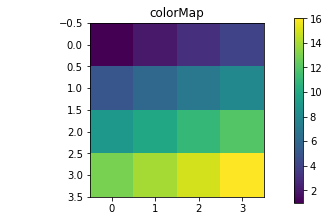

In [39]:
H = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12],
              [13, 14, 15, 16]])  # added some commas and array creation code

fig = plt.figure(figsize=(6, 3.2))

ax = fig.add_subplot(111)
ax.set_title('colorMap')
plt.imshow(H)
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='vertical')
plt.show()

In [40]:
total_lat = np.zeros(int(len_lat*len_long))
total_long = np.zeros(int(len_lat*len_long))
for i in range(len_lat * len_long):
    lat_index = i % len_lat
    total_lat[i] = lat[lat_index]
    
    long_index = int(i/len_long)
    total_long[i] = long[long_index]

In [41]:
NHIs_flat = NHIs.flat

VEL_AVGs_flat = VEL_AVGs.flat

VEL_DISPs_flat = VEL_DISPs.flat

NHI_mask = np.where(NHIs_flat >= 18.6)

NHI_final = NHIs_flat[NHI_mask]

NHI_final = NHIs_flat[NHI_mask]
VEL_AVG_final = VEL_AVGs_flat[NHI_mask]
VEL_DISP_final = VEL_DISPs_flat[NHI_mask]
long_final = total_long[NHI_mask]
lat_final = total_lat[NHI_mask]


In [42]:
hdu = fits.open(fname)[0]
wcs = WCS(hdu.header)
plt.subplot(projection=wcs)


  'DEG' -> 'deg',
  'DEG' -> 'deg',
  'M/S' -> 'm/S'. [astropy.wcs.wcs]


InvalidTransformError: ERROR 6 in wcs_units() at line 2897 of file cextern/wcslib/C/wcs.c:
In CUNIT3 : Mismatched units type 'charge': have 'm/S', want 'm/s'.


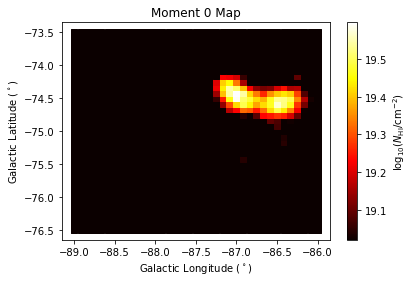

In [116]:
plt.scatter(total_long,total_lat,c=NHIs,cmap='hot',marker='s',vmin=19.02,s=43)
plt.colorbar(label=r'$\log_{10}(N_{\rm{HI}}/\rm{cm}^{-2})$')
plt.title('Moment 0 Map')
plt.xlabel(r'Galactic Longitude ($^\circ$)')

plt.ylabel(r'Galactic Latitude ($^\circ$)')
plt.savefig('Plots/Moment0.pdf')
plt.show()

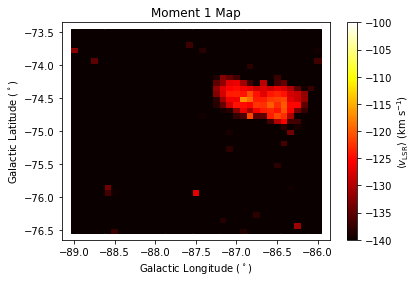

In [117]:
plt.scatter(total_long,total_lat,c=VEL_AVGs,cmap='hot',marker='s',vmin=-140,vmax=-100,s=43)
plt.title('Moment 1 Map')
plt.xlabel(r'Galactic Longitude ($^\circ$)')
plt.ylabel(r'Galactic Latitude ($^\circ$)')

plt.colorbar(label=r'$\langle v_{\rm{LSR}}\rangle$ (km s$^{-1}$)')
plt.savefig('Plots/Moment1.pdf')
plt.show()

In [144]:
np.min(VEL_DISPs)

11.315538294406217

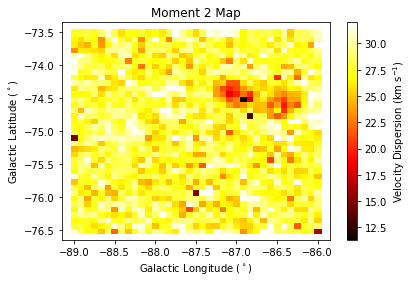

In [148]:
plt.scatter(total_long,total_lat,c=VEL_DISPs,cmap='hot',marker='s',vmin=11.315,vmax=32.,s=43)
plt.title('Moment 2 Map')
plt.xlabel(r'Galactic Longitude ($^\circ$)')
plt.ylabel(r'Galactic Latitude ($^\circ$)')

plt.colorbar(label=r'Velocity Dispersion (km s$^{-1}$)')
plt.savefig('Plots/Moment2.pdf')
plt.show()

In [123]:
alpha = m_H/c.k_B
Temps = VEL_DISPs**2 * (u.km/u.s)**2 * alpha
logT = np.log10(Temps/u.K)

In [156]:
np.mean(logT)

<Quantity 4.96509946>

In [157]:
np.median(logT)

<Quantity 4.97274226>

In [154]:
10**4.19

15488.166189124828

In [125]:
def fmt(x, pos):
    a, b = '{:.2e}'.format(x).split('e')
    b = int(b)
    return r'${} \times 10^{{{}}}$'.format(a, b)

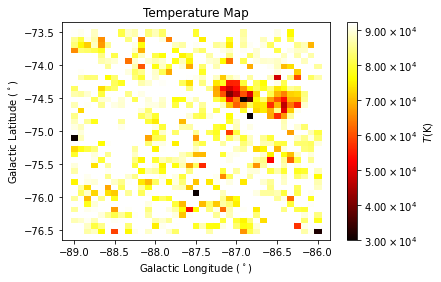

In [158]:

plt.scatter(total_long,total_lat,c=10**logT,cmap='hot',marker='s',vmin=3*10**4,vmax=10**4.965,s=43)
plt.title('Temperature Map')
plt.xlabel(r'Galactic Longitude ($^\circ$)')
plt.ylabel(r'Galactic Latitude ($^\circ$)')

plt.colorbar(label=r'$T(\rm{K})$', format=ticker.FuncFormatter(fmt))
plt.savefig('Plots/Temp_Plot.pdf')
plt.show()

In [46]:
plt.subplot(projection=wcs)
plt.imshow(hdu.data, vmin=-2.e-5, vmax=2.e-4, origin='lower')
plt.grid(color='white', ls='solid')
plt.xlabel('Galactic Longitude')
plt.ylabel('Galactic Latitude')

NameError: name 'wcs' is not defined

# Mass estimation

\begin{equation}
M_{\rm{H I}} = m_p\int\int m_{\rm{H I}}(\Omega)d\Omega
\end{equation}



\begin{equation}
\implies M_{\rm{H I}} = d^2m_p\int\int N_{\rm{H I}}(x_\ell,x_b)d\Omega
\end{equation}

In [47]:
total_lat = np.zeros(int(len_lat*len_long))
total_long = np.zeros(int(len_lat*len_long))
for i in range(len_lat * len_long):
    lat_index = i % len_lat
    total_lat[i] = lat[lat_index]
    
    long_index = int(i/len_long)
    total_long[i] = long[long_index]

In [48]:
NHIs_flat = NHIs.flat

VEL_AVGs_flat = VEL_AVGs.flat

VEL_DISPs_flat = VEL_DISPs.flat

NHI_mask = np.where(NHIs_flat >= 19.02)

NHI_final = NHIs_flat[NHI_mask]

NHI_final = NHIs_flat[NHI_mask]
VEL_AVG_final = VEL_AVGs_flat[NHI_mask]
VEL_DISP_final = VEL_DISPs_flat[NHI_mask]
long_final = total_long[NHI_mask]
lat_final = total_lat[NHI_mask]


In [49]:
def deg_to_rad(angle):
    angle_rad = angle * (np.pi)/180.
    return angle_rad

In [50]:
pre_Mass = 0
d_ell = deg_to_rad(long[1]- long[0])
db = deg_to_rad(lat[1] - lat[0])
for i in range(len(long_final)):
    b = lat_final[i]
    b_rad = deg_to_rad(b)
        
        
    pre_Mass += (10**NHIs_flat[i]/(u.cm**2)) * d_ell * db 
        

In [173]:
mult_factor_min = m_H *50**2*u.kpc**2
mult_factor_max = m_H *150**2*u.kpc**2

In [174]:
Mass_HI_min = mult_factor_min * pre_Mass
Mass_HI_max = mult_factor_max * pre_Mass


In [175]:
Mass_HI_min = Mass_HI_min.to('M_sun')
Mass_HI_max = Mass_HI_max.to('M_sun')


In [176]:
Mass_HI_min

<Quantity 22988.33938048 solMass>

In [177]:
Mass_HI_max

<Quantity 206895.0544243 solMass>

In [178]:
ion_frac_min = 0.5
ion_frac_max = 2./3

In [179]:
Mass_HII_min = Mass_HI_min 

In [180]:
Mass_HII_max = 2 * Mass_HI_max
Mass_HII_max

<Quantity 413790.1088486 solMass>

In [181]:
Mass_Htot_min = Mass_HI_min + Mass_HII_min

In [182]:
np.log10(Mass_HII_min/u.M_sun)

<Quantity 4.3615076>

In [183]:
np.log10(Mass_HII_max/u.M_sun)

<Quantity 5.61678011>

In [184]:
np.log10(Mass_Htot_min/u.M_sun)

<Quantity 4.6625376>

In [185]:
Mass_Htot_max = Mass_HI_max + Mass_HII_max

In [186]:
Mass_Htot_max - Mass_Htot_min

<Quantity 574708.48451194 solMass>

In [187]:
np.log10(Mass_Htot_max/u.M_sun)

<Quantity 5.79287136>

In [188]:
Mass_Htot_max

<Quantity 620685.1632729 solMass>

In [190]:
T = m_H * (20*u.km/u.s)**2/c.k_B

In [191]:
T.to('K')

<Quantity 48485.3967101 K>